In [1]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install geopandas
!pip install pandas
!pip install openpyxl
!pip install matplotlib
!pip install folium
!pip install mapclassify
!pip install seaborn
!pip install rasterio geopandas shapely

In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import folium
import mapclassify
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

In [5]:
#degradacao = gpd.read_file("C:/Users/lucci/OneDrive/Documentos/OneDrive/11_SOS_AMAZON/01_TrajetoryDegrad/01_Dados/04_PROCESSADOS/03_DEGRADACAO_DESMATAMENTO/Trajetoria_DEGRAD_DETER_PRODES_2007_2025_pol_FINAL.gpkg")

In [4]:
degradacao = gpd.read_file("C:/Users/lucci/OneDrive/Documentos/OneDrive/11_SOS_AMAZON/01_TrajetoryDegrad/01_Dados/04_PROCESSADOS/03_DEGRADACAO_DESMATAMENTO/Trajetoria_DEGRAD_DETER_PRODES_2007_2025_pol_FINAL_class.gpkg")

In [5]:
amz = gpd.read_file("C:/Users/lucci/OneDrive/Documentos/OneDrive/04_AUX/Amazonia.shp")


In [10]:
# Use spatial join to find polygons in gdf1 that intersect gdf2
dg = gpd.sjoin(dg, amz, how="inner", predicate="intersects")
dg.head()

,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,...,years_after_degrad,deforest,seq0824,deforestation,count0824,dg0824_desm,geometry,index_right,Bioma,CD_Bioma
0,0,0,0,0,0,0,0,0,0,0,...,NaN,1,4,1,4,both,"MULTIPOLYGON (((4876148.755 8749082.353, 48761...",0,Amazônia,1
1,0,1,1,0,0,0,0,1,1,0,...,NaN,1,8,1,8,both,"MULTIPOLYGON (((5232158.859 8693312.155, 52321...",0,Amazônia,1
2,0,1,1,1,0,0,0,0,0,0,...,NaN,1,7,1,7,both,"MULTIPOLYGON (((5018567.944 8906527.269, 50185...",0,Amazônia,1
3,0,1,0,1,0,0,0,0,0,0,...,NaN,1,6,1,6,both,"MULTIPOLYGON (((5018581.093 8906518.42, 501856...",0,Amazônia,1
4,0,1,0,0,0,0,0,0,0,0,...,NaN,1,5,1,5,both,"MULTIPOLYGON (((5018601.851 8906431.342, 50186...",0,Amazônia,1


In [ ]:
'''
output_path = "C:/Users/lucci/OneDrive/Documentos/OneDrive/11_SOS_AMAZON/01_TrajetoryDegrad/01_Dados/04_PROCESSADOS/03_DEGRADACAO_DESMATAMENTO/Trajetoria_DEGRAD_DETER_PRODES_2007_2025_pol_FINAL_class_biomaAMZ.gpkg"
dg.to_file(output_path, layer="dg", driver="GPKG")

In [6]:
degradacao = gpd.read_file("C:/Users/lucci/OneDrive/Documentos/OneDrive/11_SOS_AMAZON/01_TrajetoryDegrad/01_Dados/04_PROCESSADOS/03_DEGRADACAO_DESMATAMENTO/Trajetoria_DEGRAD_DETER_PRODES_2007_2025_pol_FINAL_class.gpkg")

In [7]:
dg=degradacao

In [8]:
target_crs = "EPSG:5880"
amz = amz.to_crs(target_crs)
dg = dg.to_crs(target_crs)

In [9]:
# If you only want the original geometries from gdf1:
dg = dg[dg.columns]

In [ ]:
'''
# Apenas AMZ
dg = gpd.overlay(degradacao, amz, how='intersection')

In [10]:
dg.head()

,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,...,deforestation,dg0824_desm,index_right,Bioma,CD_Bioma,seq0824,count0824,last_degrad,class2,geometry
0,0,0,0,0,0,0,0,0,0,0,...,1,both,0,Amazônia,1,00000000001001111,5,2024.0,df_dg,"MULTIPOLYGON (((4876148.755 8749082.353, 48761..."
1,0,1,1,0,0,0,0,1,1,0,...,1,both,0,Amazônia,1,11000011001010111,9,2024.0,df_dg,"MULTIPOLYGON (((5232158.859 8693312.155, 52321..."
2,0,1,1,1,0,0,0,0,0,0,...,1,both,0,Amazônia,1,11100000001010111,8,2024.0,df_dg,"MULTIPOLYGON (((5018567.944 8906527.269, 50185..."
3,0,1,0,1,0,0,0,0,0,0,...,1,both,0,Amazônia,1,10100000001010111,7,2024.0,df_dg,"MULTIPOLYGON (((5018581.093 8906518.42, 501856..."
4,0,1,0,0,0,0,0,0,0,0,...,1,both,0,Amazônia,1,10000000001010111,6,2024.0,df_dg,"MULTIPOLYGON (((5018601.851 8906431.342, 50186..."


In [11]:
dg['area_km2'] = dg.geometry.area/ 1_000_000

In [12]:
dg = dg.drop(columns=['seq0824'])
dg = dg.drop(columns=['count0824'])

In [13]:
dg.head()

,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,...,years_after_degrad,deforest,deforestation,dg0824_desm,index_right,Bioma,CD_Bioma,last_degrad,class2,geometry
0,0,0,0,0,0,0,0,0,0,0,...,0.0,1,1,both,0,Amazônia,1,2024.0,df_dg,"MULTIPOLYGON (((4876148.755 8749082.353, 48761..."
1,0,1,1,0,0,0,0,1,1,0,...,0.0,1,1,both,0,Amazônia,1,2024.0,df_dg,"MULTIPOLYGON (((5232158.859 8693312.155, 52321..."
2,0,1,1,1,0,0,0,0,0,0,...,0.0,1,1,both,0,Amazônia,1,2024.0,df_dg,"MULTIPOLYGON (((5018567.944 8906527.269, 50185..."
3,0,1,0,1,0,0,0,0,0,0,...,0.0,1,1,both,0,Amazônia,1,2024.0,df_dg,"MULTIPOLYGON (((5018581.093 8906518.42, 501856..."
4,0,1,0,0,0,0,0,0,0,0,...,0.0,1,1,both,0,Amazônia,1,2024.0,df_dg,"MULTIPOLYGON (((5018601.851 8906431.342, 50186..."


In [14]:
print(dg.columns.tolist())

['2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'class', 'year', 'area_km2', 'source', 'access', 'ID', 'prodes', 'years_after_degrad', 'deforest', 'deforestation', 'dg0824_desm', 'index_right', 'Bioma', 'CD_Bioma', 'last_degrad', 'class2', 'geometry']


In [15]:
dg['2025'].describe()

count     1591889
unique          2
top             0
freq      1343394
Name: 2025, dtype: object

In [17]:
# Define the year range you want to include in the sequence
years_to_count = [str(y) for y in range(2008, 2025)]  # 2008–2025 inclusive

# Create the sequence column by joining the yearly values as strings
dg["seq0824"] = dg[years_to_count].astype(str).agg("".join, axis=1)

# Optional sanity check
print(dg[["2024", "seq0824"]].head())

   2024            seq0824
0     1  00000000001001111
1     1  11000011001010111
2     1  11100000001010111
3     1  10100000001010111
4     1  10000000001010111


In [18]:
# Ensure all year columns are numeric (convert '0'/'1' strings to integers)
dg[years_to_count] = dg[years_to_count].apply(pd.to_numeric, errors='coerce').fillna(0).astype(int)

# Count how many times the event occurred (1) from 2008–2025
dg["count0824"] = dg[years_to_count].sum(axis=1)
dg.head()

,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,...,deforestation,dg0824_desm,index_right,Bioma,CD_Bioma,last_degrad,class2,geometry,seq0824,count0824
0,0,0,0,0,0,0,0,0,0,0,...,1,both,0,Amazônia,1,2024.0,df_dg,"MULTIPOLYGON (((4876148.755 8749082.353, 48761...",00000000001001111,5
1,0,1,1,0,0,0,0,1,1,0,...,1,both,0,Amazônia,1,2024.0,df_dg,"MULTIPOLYGON (((5232158.859 8693312.155, 52321...",11000011001010111,9
2,0,1,1,1,0,0,0,0,0,0,...,1,both,0,Amazônia,1,2024.0,df_dg,"MULTIPOLYGON (((5018567.944 8906527.269, 50185...",11100000001010111,8
3,0,1,0,1,0,0,0,0,0,0,...,1,both,0,Amazônia,1,2024.0,df_dg,"MULTIPOLYGON (((5018581.093 8906518.42, 501856...",10100000001010111,7
4,0,1,0,0,0,0,0,0,0,0,...,1,both,0,Amazônia,1,2024.0,df_dg,"MULTIPOLYGON (((5018601.851 8906431.342, 50186...",10000000001010111,6


In [19]:
CHECK = dg[(dg['count0824'] > 0) & (dg["2025"]==1)]
print(CHECK[['count0824', '2025']])

Empty DataFrame
Columns: [count0824, 2025]
Index: []


In [20]:
# --- Select degradation-year columns: 2008–2024 ---
year_cols = [
    c for c in dg.columns 
    if c.isdigit() and 2007 < int(c) < 2025
]

def compute_last_degrad_and_delay(row):
    # Collect degradation years
    degrad_years = []
    for col in year_cols:
        val = pd.to_numeric(row[col], errors="coerce")
        if val == 1:
            degrad_years.append(int(col))

    if len(degrad_years) == 0:
        return pd.Series([np.nan, np.nan])

    # Last degradation year
    last_degrad = int(max(degrad_years))

    # Deforestation year
    prodes_year = pd.to_numeric(row.get("prodes", np.nan), errors="coerce")
    if np.isnan(prodes_year) or prodes_year <= 0:
        return pd.Series([last_degrad, np.nan])

    prodes_year = int(prodes_year)

    # Difference
    diff = prodes_year - last_degrad
    if diff < 0:
        years_after = np.nan
    else:
        years_after = diff

    return pd.Series([last_degrad, years_after])


# --- Apply and create new columns ---
dg[["last_degrad", "years_after_degrad"]] = dg.apply(
    compute_last_degrad_and_delay, axis=1
)

In [22]:
# Columns between 2008 and 2024
year_cols = [
    c for c in dg.columns 
    if c.isdigit() and 2007 < int(c) < 2025
]

# Extract the first degradation year
def get_first_degrad(row):
    degrad_years = [
        int(c) for c in year_cols
        if pd.to_numeric(row[c], errors="coerce") == 1
    ]
    return min(degrad_years) if degrad_years else np.nan

# Add the new column
dg["first_degrad"] = dg.apply(get_first_degrad, axis=1)


In [23]:
dg["deforest"] = (pd.to_numeric(dg["prodes"], errors="coerce") > 0).astype(int)

In [24]:
print(dg[["deforestation",'deforest',"prodes", "seq0824",'first_degrad', 'last_degrad','count0824','years_after_degrad']].head())

   deforestation  deforest  prodes            seq0824  first_degrad  \
0              1         1    2024  00000000001001111        2018.0   
1              1         1    2024  11000011001010111        2008.0   
2              1         1    2024  11100000001010111        2008.0   
3              1         1    2024  10100000001010111        2008.0   
4              1         1    2024  10000000001010111        2008.0   

   last_degrad  count0824  years_after_degrad  
0       2024.0          5                 0.0  
1       2024.0          9                 0.0  
2       2024.0          8                 0.0  
3       2024.0          7                 0.0  
4       2024.0          6                 0.0  


In [25]:
dg["years_after_degrad"].describe()

count    517055.000000
mean          3.059435
std           3.306178
min           0.000000
25%           0.000000
50%           2.000000
75%           5.000000
max          16.000000
Name: years_after_degrad, dtype: float64

In [26]:
print(dg.columns.tolist())

['2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', 'class', 'year', 'area_km2', 'source', 'access', 'ID', 'prodes', 'years_after_degrad', 'deforest', 'deforestation', 'dg0824_desm', 'index_right', 'Bioma', 'CD_Bioma', 'last_degrad', 'class2', 'geometry', 'seq0824', 'count0824', 'first_degrad']


In [27]:
# 2️⃣ Affected area (km²)
area_by_count = dg.groupby("count0824")["area_km2"].sum().reset_index()

In [28]:
dg.head()

,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,...,dg0824_desm,index_right,Bioma,CD_Bioma,last_degrad,class2,geometry,seq0824,count0824,first_degrad
0,0,0,0,0,0,0,0,0,0,0,...,both,0,Amazônia,1,2024.0,df_dg,"MULTIPOLYGON (((4876148.755 8749082.353, 48761...",00000000001001111,5,2018.0
1,0,1,1,0,0,0,0,1,1,0,...,both,0,Amazônia,1,2024.0,df_dg,"MULTIPOLYGON (((5232158.859 8693312.155, 52321...",11000011001010111,9,2008.0
2,0,1,1,1,0,0,0,0,0,0,...,both,0,Amazônia,1,2024.0,df_dg,"MULTIPOLYGON (((5018567.944 8906527.269, 50185...",11100000001010111,8,2008.0
3,0,1,0,1,0,0,0,0,0,0,...,both,0,Amazônia,1,2024.0,df_dg,"MULTIPOLYGON (((5018581.093 8906518.42, 501856...",10100000001010111,7,2008.0
4,0,1,0,0,0,0,0,0,0,0,...,both,0,Amazônia,1,2024.0,df_dg,"MULTIPOLYGON (((5018601.851 8906431.342, 50186...",10000000001010111,6,2008.0


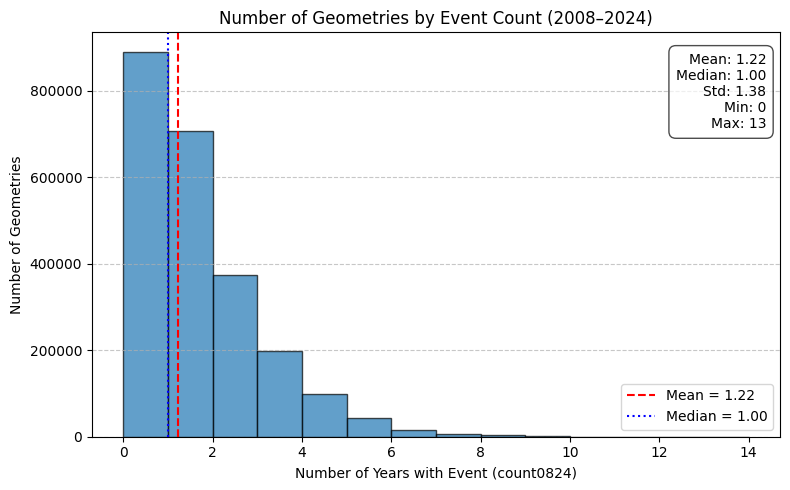

In [28]:
# --- Compute summary statistics ---
mean_val = dg["count0824"].mean()
median_val = dg["count0824"].median()
std_val = dg["count0824"].std()
min_val = dg["count0824"].min()
max_val = dg["count0824"].max()

# --- Plot histogram ---
plt.figure(figsize=(8, 5))
n, bins, patches = plt.hist(
    dg["count0824"],
    bins=range(0, dg["count0824"].max() + 2),
    edgecolor="black",
    alpha=0.7
)

# Add vertical lines for mean and median
plt.axvline(mean_val, color="red", linestyle="dashed", linewidth=1.5, label=f"Mean = {mean_val:.2f}")
plt.axvline(median_val, color="blue", linestyle="dotted", linewidth=1.5, label=f"Median = {median_val:.2f}")

# --- Add summary statistics as text box ---
stats_text = (
    f"Mean: {mean_val:.2f}\n"
    f"Median: {median_val:.2f}\n"
    f"Std: {std_val:.2f}\n"
    f"Min: {min_val}\n"
    f"Max: {max_val}"
)
plt.gca().text(
    0.98, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7)
)

# --- Final styling ---
plt.title("Number of Geometries by Event Count (2008–2024)")
plt.xlabel("Number of Years with Event (count0824)")
plt.ylabel("Number of Geometries")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


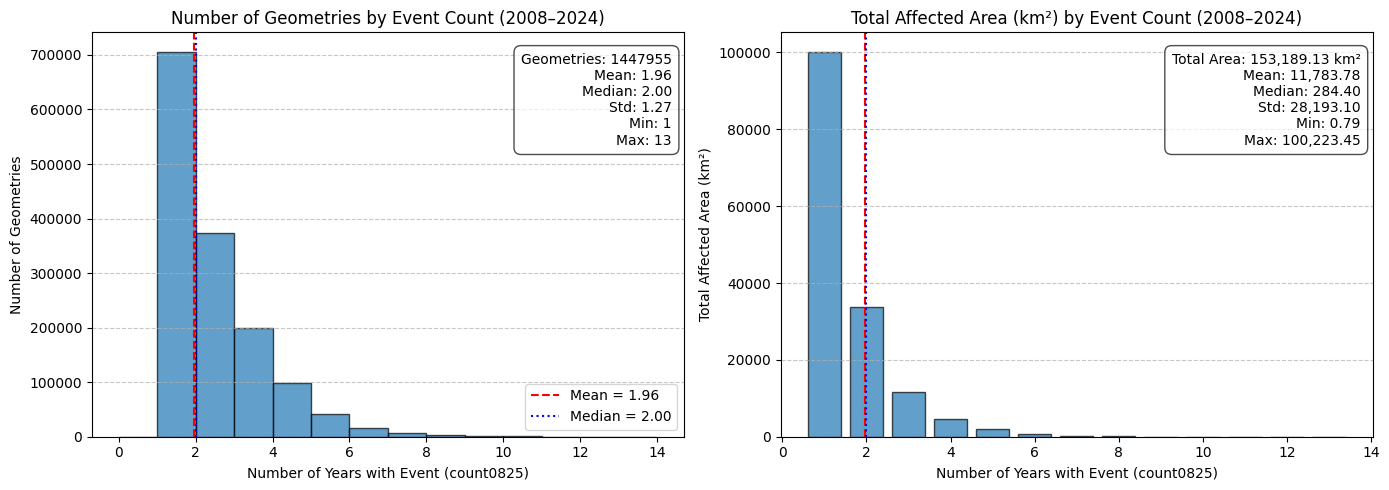

In [29]:
dg_1 = dg[dg["count0824"] > 0].copy()

# --- Compute summary stats for count0825 (number of geometries) ---
mean_count = dg_1["count0824"].mean()
median_count = dg_1["count0824"].median()
std_count = dg_1["count0824"].std()
min_count = dg_1["count0824"].min()
max_count = dg_1["count0824"].max()
n_geom = len(dg_1)

# --- Group area by event count and compute summary stats ---
area_by_count = dg_1.groupby("count0824")["area_km2"].sum().reset_index()
mean_area = area_by_count["area_km2"].mean()
median_area = area_by_count["area_km2"].median()
std_area = area_by_count["area_km2"].std()
min_area = area_by_count["area_km2"].min()
max_area = area_by_count["area_km2"].max()
total_area = dg_1["area_km2"].sum()

# --- Create figure and subplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ======================================================
# 1️⃣ Histogram — Number of Geometries
# ======================================================
axes[0].hist(
    dg_1["count0824"],
    bins=range(0, dg["count0824"].max() + 2),
    edgecolor="black",
    alpha=0.7
)
axes[0].axvline(mean_count, color="red", linestyle="dashed", linewidth=1.5, label=f"Mean = {mean_count:.2f}")
axes[0].axvline(median_count, color="blue", linestyle="dotted", linewidth=1.5, label=f"Median = {median_count:.2f}")

stats_text1 = (
    f"Geometries: {n_geom}\n"
    f"Mean: {mean_count:.2f}\n"
    f"Median: {median_count:.2f}\n"
    f"Std: {std_count:.2f}\n"
    f"Min: {min_count}\n"
    f"Max: {max_count}"
)
axes[0].text(
    0.98, 0.95, stats_text1,
    transform=axes[0].transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7)
)
axes[0].set_title("Number of Geometries by Event Count (2008–2024)")
axes[0].set_xlabel("Number of Years with Event (count0825)")
axes[0].set_ylabel("Number of Geometries")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)
axes[0].legend()

# ======================================================
# 2️⃣ Bar Chart — Total Affected Area (km²)
# ======================================================
axes[1].bar(
    area_by_count["count0824"],
    area_by_count["area_km2"],
    edgecolor="black",
    alpha=0.7
)

axes[1].axvline(mean_count, color="red", linestyle="dashed", linewidth=1.5, label=f"Mean = {mean_count:.2f}")
axes[1].axvline(median_count, color="blue", linestyle="dotted", linewidth=1.5, label=f"Median = {median_count:.2f}")

stats_text2 = (
    f"Total Area: {total_area:,.2f} km²\n"
    f"Mean: {mean_area:,.2f}\n"
    f"Median: {median_area:,.2f}\n"
    f"Std: {std_area:,.2f}\n"
    f"Min: {min_area:,.2f}\n"
    f"Max: {max_area:,.2f}"
)
axes[1].text(
    0.98, 0.95, stats_text2,
    transform=axes[1].transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7)
)
axes[1].set_title("Total Affected Area (km²) by Event Count (2008–2024)")
axes[1].set_xlabel("Number of Years with Event (count0825)")
axes[1].set_ylabel("Total Affected Area (km²)")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# --- Final layout ---
plt.tight_layout()
plt.show()


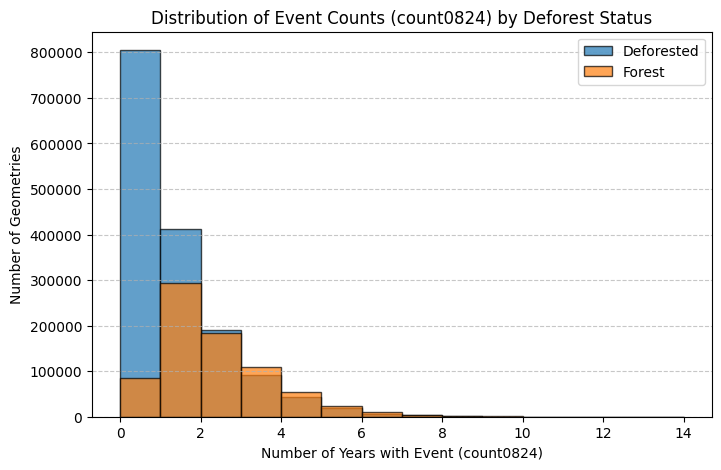

In [30]:
# Separate data by deforest category
deforest_1 = dg[dg['deforest'] == 1]["count0824"]
deforest_0 = dg[dg['deforest'] == 0]["count0824"]

# Define bins
bins = range(0, dg["count0824"].max() + 2)

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(deforest_1, bins=bins, alpha=0.7, label="Deforested", edgecolor="black")
plt.hist(deforest_0, bins=bins, alpha=0.7, label="Forest", edgecolor="black")

# Add labels and title
plt.title("Distribution of Event Counts (count0824) by Deforest Status")
plt.xlabel("Number of Years with Event (count0824)")
plt.ylabel("Number of Geometries")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


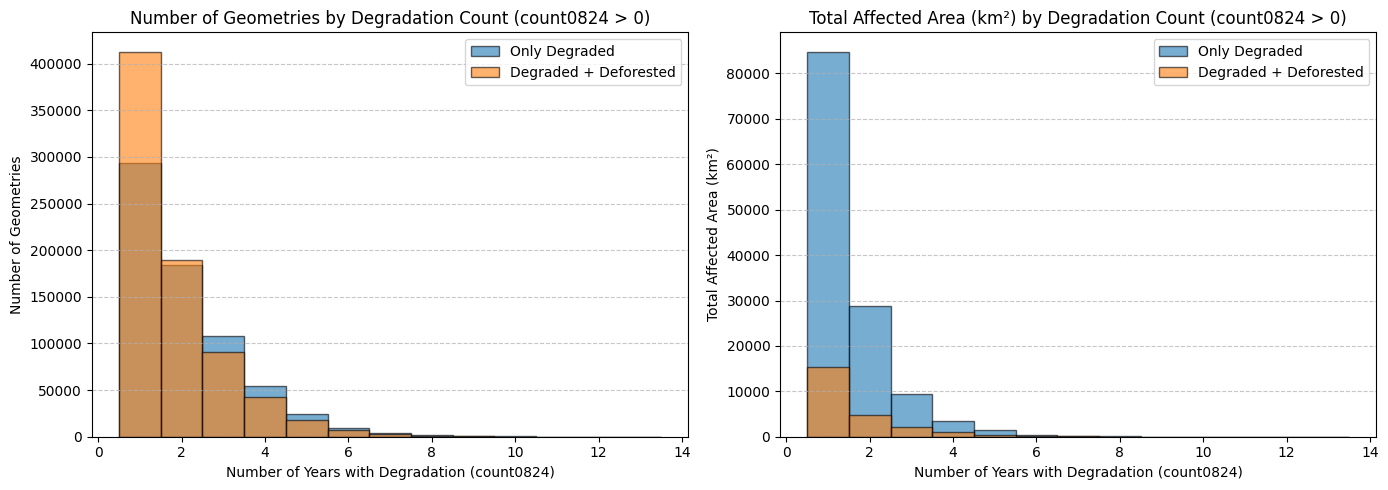

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# --- Filter out count0824 == 0 ---
dg_pos = dg[dg["count0824"] > 0].copy()

deforest_1 = dg_pos[dg_pos["deforest"] == 1]
deforest_0 = dg_pos[dg_pos["deforest"] == 0]

# --- Bins for integer event counts ---
bins = np.arange(1, dg_pos["count0824"].max() + 2) - 0.5  # start from 1 now!

# --- Create figure and axes ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ======================================================
# 1️⃣ Left: Number of geometries (frequency)
# ======================================================
axes[0].hist(
    deforest_0["count0824"],
    bins=bins,
    edgecolor="black",
    alpha=0.6,
    label="Only Degraded"
)
axes[0].hist(
    deforest_1["count0824"],
    bins=bins,
    edgecolor="black",
    alpha=0.6,
    label="Degraded + Deforested"
)
axes[0].set_title("Number of Geometries by Degradation Count (count0824 > 0)")
axes[0].set_xlabel("Number of Years with Degradation (count0824)")
axes[0].set_ylabel("Number of Geometries")
axes[0].legend()
axes[0].grid(axis="y", linestyle="--", alpha=0.7)

# ======================================================
# 2️⃣ Right: Total affected area (weighted by km²)
# ======================================================
axes[1].hist(
    deforest_0["count0824"],
    bins=bins,
    weights=deforest_0["area_km2"],
    edgecolor="black",
    alpha=0.6,
    label="Only Degraded"
)
axes[1].hist(
    deforest_1["count0824"],
    bins=bins,
    weights=deforest_1["area_km2"],
    edgecolor="black",
    alpha=0.6,
    label="Degraded + Deforested"
)
axes[1].set_title("Total Affected Area (km²) by Degradation Count (count0824 > 0)")
axes[1].set_xlabel("Number of Years with Degradation (count0824)")
axes[1].set_ylabel("Total Affected Area (km²)")
axes[1].legend()
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# --- Final layout ---
plt.tight_layout()
plt.show()


In [32]:
dg.head()

,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,...,deforest,deforestation,dg0824_desm,index_right,Bioma,CD_Bioma,geometry,seq0824,count0824,last_degrad
0,0,0,0,0,0,0,0,0,0,0,...,1,1,both,0,Amazônia,1,"MULTIPOLYGON (((4876148.755 8749082.353, 48761...",00000000001001111,5,2024.0
1,0,1,1,0,0,0,0,1,1,0,...,1,1,both,0,Amazônia,1,"MULTIPOLYGON (((5232158.859 8693312.155, 52321...",11000011001010111,9,2024.0
2,0,1,1,1,0,0,0,0,0,0,...,1,1,both,0,Amazônia,1,"MULTIPOLYGON (((5018567.944 8906527.269, 50185...",11100000001010111,8,2024.0
3,0,1,0,1,0,0,0,0,0,0,...,1,1,both,0,Amazônia,1,"MULTIPOLYGON (((5018581.093 8906518.42, 501856...",10100000001010111,7,2024.0
4,0,1,0,0,0,0,0,0,0,0,...,1,1,both,0,Amazônia,1,"MULTIPOLYGON (((5018601.851 8906431.342, 50186...",10000000001010111,6,2024.0


In [33]:
dg["dg0824_desm"] = np.select(
    [
        (dg["count0824"] > 0) & (dg["deforest"] == 1),  # condition 1
        (dg["count0824"] > 0) & (dg["deforest"] == 0)   # condition 2
    ],
    [
        "both",         # value if condition 1 is True
        "only_degrad"   # value if condition 2 is True
    ],
    default=None        # optional: what to assign if neither condition is met
)

# Optional: preview the result
print(dg[["count0824", "deforest", "dg0824_desm"]].head())

   count0824  deforest dg0824_desm
0          5         1        both
1          9         1        both
2          8         1        both
3          7         1        both
4          6         1        both


In [34]:
dg["class"] = np.select(
    [
        (dg["count0824"] == 0 ) & (dg["deforest"] == 1),  
        (dg["count0824"] > 1) & (dg["deforest"] == 0),
        (dg["count0824"] == 1) & (dg["deforest"] == 0),
        (dg["count0824"] >= 1) & (dg["deforest"] == 1)
    ],
    [
        "Only deforestation",         
        "Persistent degradation",
        "Single event of degradation",
        "Deforestation after degradation"
    ],
    default=None        # optional: what to assign if neither condition is met
)

# Optional: preview the result
print(dg[["count0824", "deforest", "class"]].head())

   count0824  deforest                            class
0          5         1  Deforestation after degradation
1          9         1  Deforestation after degradation
2          8         1  Deforestation after degradation
3          7         1  Deforestation after degradation
4          6         1  Deforestation after degradation


In [32]:
# Create a copy so we don't overwrite original data
result_plot = dg.copy()

# Unified year for plotting
result_plot["first_year_plot"] = result_plot["first_degrad"]

# For class == "Only deforestation", replace with prodes year
mask_only_def = result_plot["class"] == "Only deforestation"
result_plot.loc[mask_only_def, "first_year_plot"] = result_plot.loc[mask_only_def, "prodes"]


In [33]:
result_plot = result_plot[result_plot["first_year_plot"] <= 2023]

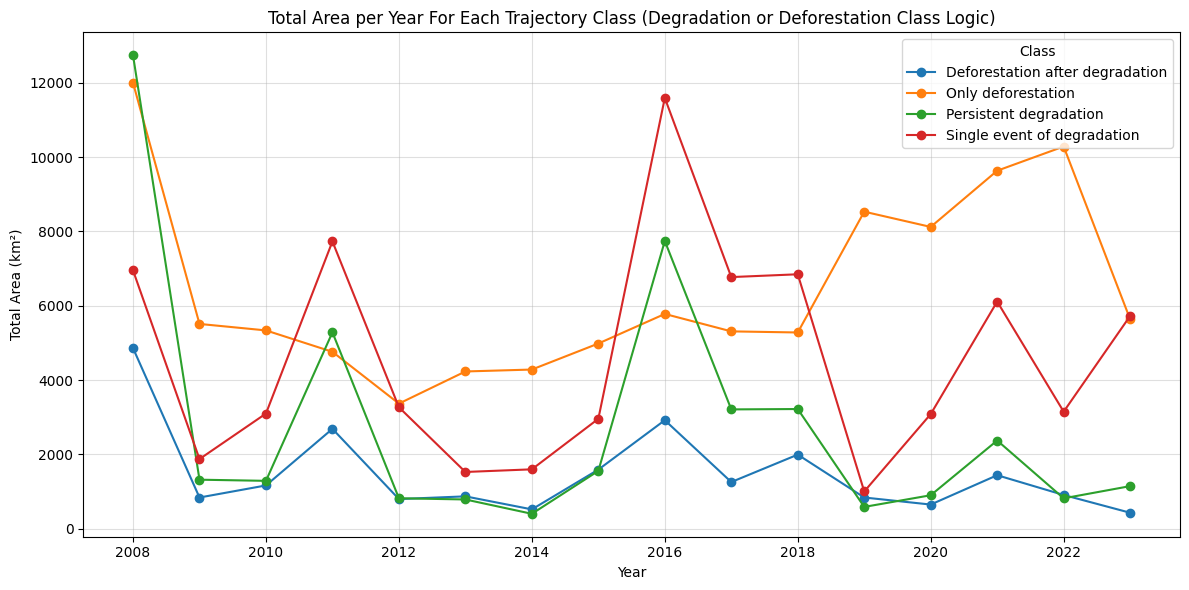

In [35]:
import matplotlib.pyplot as plt

# Group by the unified year + class
grouped = (
    result_plot.groupby(["first_year_plot", "class"])["area_km2"]
    .sum()
    .reset_index()
)

# Pivot for plotting
pivot = grouped.pivot(index="first_year_plot", columns="class", values="area_km2")

# Plot
plt.figure(figsize=(12,6))

for c in pivot.columns:
    plt.plot(pivot.index, pivot[c], marker="o", label=str(c))

plt.title("Total Area per Year For Each Trajectory Class (Degradation or Deforestation Class Logic)")
plt.xlabel("Year")
plt.ylabel("Total Area (km²)")
plt.grid(alpha=0.4)
plt.legend(title="Class")
plt.tight_layout()
plt.show()


In [48]:
# If you want to save the result to a new GPKG layer:
output_path = "C:/Users/lucci/OneDrive/Documentos/OneDrive/11_SOS_AMAZON/01_TrajetoryDegrad/01_Dados/04_PROCESSADOS/03_DEGRADACAO_DESMATAMENTO/Trajetoria_DEGRAD_DETER_PRODES_2007_2025_pol_FINAL_class.gpkg"
dg.to_file(output_path, layer="dg", driver="GPKG")

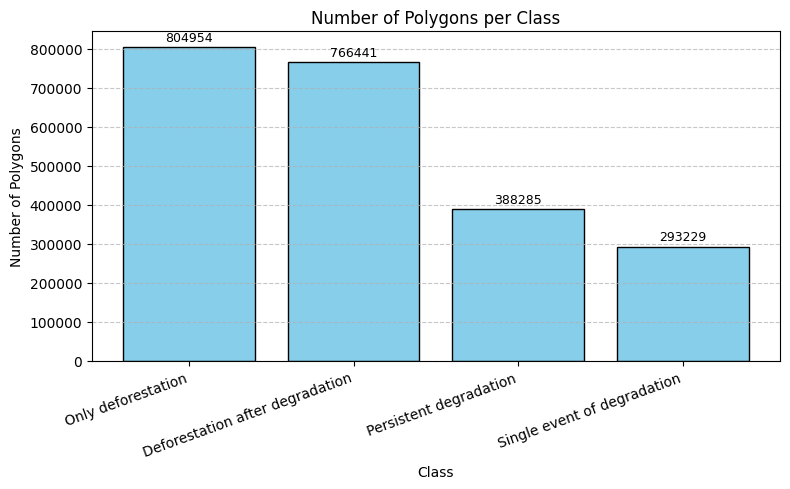

In [35]:
# Count number of polygons per class
class_counts = dg["class"].value_counts().reset_index()
class_counts.columns = ["class", "count"]

# Plot
plt.figure(figsize=(8, 5))
plt.bar(class_counts["class"], class_counts["count"], color="skyblue", edgecolor="black")

# Add labels
plt.title("Number of Polygons per Class")
plt.xlabel("Class")
plt.ylabel("Number of Polygons")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Optional: add count labels above bars
for i, v in enumerate(class_counts["count"]):
    plt.text(i, v + (max(class_counts["count"]) * 0.01), str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


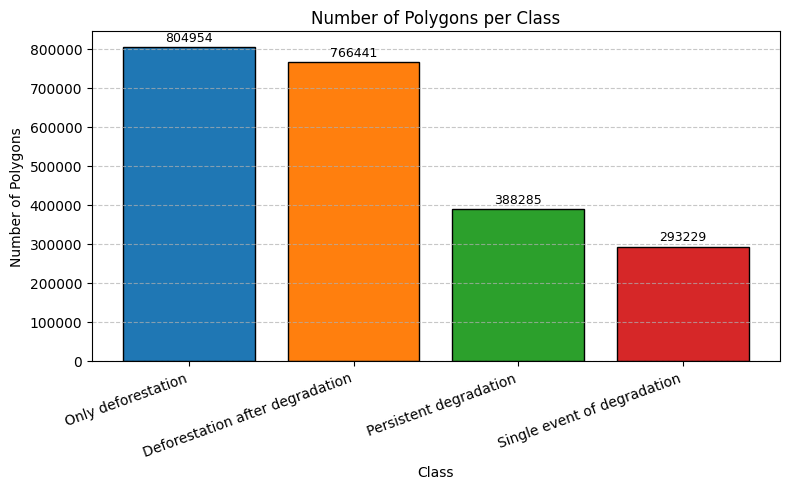

In [36]:
# Count number of polygons per class
class_counts = dg["class"].value_counts().reset_index()
class_counts.columns = ["class", "count"]

# Define a specific color for each class (in order)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # blue, orange, green, red

# Plot
plt.figure(figsize=(8, 5))
plt.bar(class_counts["class"], class_counts["count"], color=colors, edgecolor="black")

# Add labels
plt.title("Number of Polygons per Class")
plt.xlabel("Class")
plt.ylabel("Number of Polygons")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add count labels above bars
for i, v in enumerate(class_counts["count"]):
    plt.text(i, v + (max(class_counts["count"]) * 0.01), str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

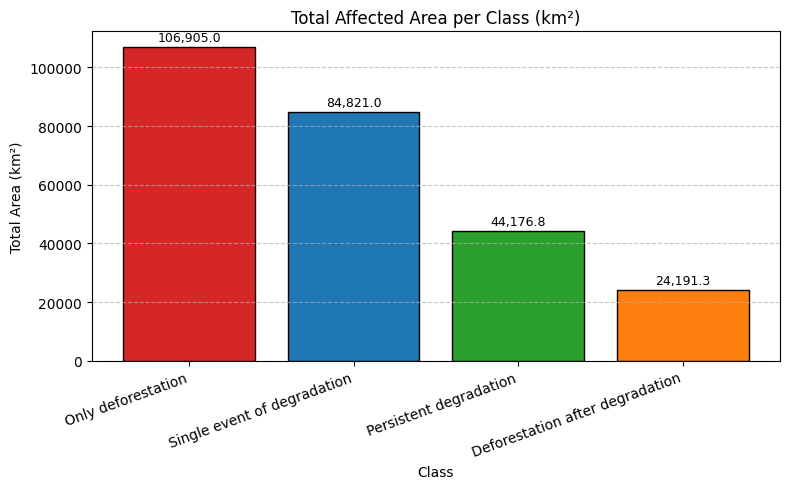

In [37]:
# Group by class and sum the area
class_area = dg.groupby("class")["area_km2"].sum().reset_index()
class_area = class_area.sort_values("area_km2", ascending=False)

# Define colors for each class (optional but nice)
color_map = {
    "Only deforestation": "#d62728",          # red
    "Persistent degradation": "#2ca02c",      # green
    "Single event of degradation": "#1f77b4", # blue
    "Deforestation after degradation": "#ff7f0e"  # orange
}
colors = [color_map.get(c, "gray") for c in class_area["class"]]

# Plot total area per class
plt.figure(figsize=(8, 5))
plt.bar(class_area["class"], class_area["area_km2"], color=colors, edgecolor="black")

# Labels and title
plt.title("Total Affected Area per Class (km²)")
plt.xlabel("Class")
plt.ylabel("Total Area (km²)")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Add text labels on top of bars
for i, v in enumerate(class_area["area_km2"]):
    plt.text(i, v + (max(class_area["area_km2"]) * 0.01), f"{v:,.1f}", 
             ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


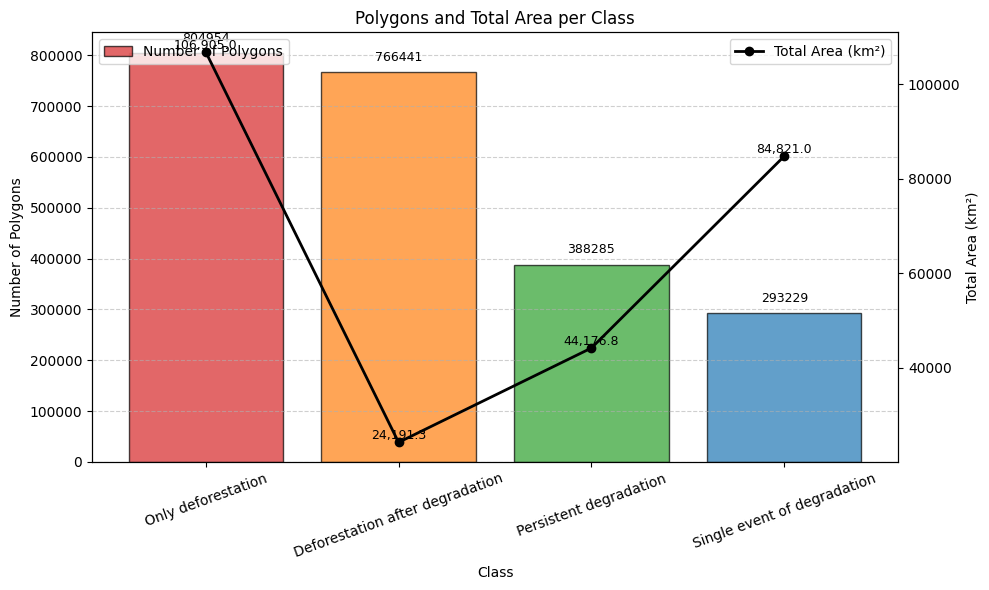

In [38]:
# Aggregate data
class_summary = (
    dg.groupby("class")
    .agg(
        num_polygons=("class", "count"),
        total_area_km2=("area_km2", "sum")
    )
    .reset_index()
)

# Keep classes in a consistent order (optional)
class_summary = class_summary.sort_values("num_polygons", ascending=False)

# Define colors
color_map = {
    "Only deforestation": "#d62728",          # red
    "Persistent degradation": "#2ca02c",      # green
    "Single event of degradation": "#1f77b4", # blue
    "Deforestation after degradation": "#ff7f0e"  # orange
}
colors = [color_map.get(c, "gray") for c in class_summary["class"]]

# Create figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for number of polygons (left y-axis)
bars = ax1.bar(class_summary["class"], class_summary["num_polygons"],
               color=colors, edgecolor="black", alpha=0.7, label="Number of Polygons")

ax1.set_xlabel("Class")
ax1.set_ylabel("Number of Polygons", color="black")
ax1.tick_params(axis="y", labelcolor="black")
ax1.tick_params(axis="x", rotation=20)

# Second y-axis for total area
ax2 = ax1.twinx()
ax2.plot(class_summary["class"], class_summary["total_area_km2"],
         color="black", marker="o", linewidth=2, label="Total Area (km²)")

ax2.set_ylabel("Total Area (km²)", color="black")
ax2.tick_params(axis="y", labelcolor="black")

# Grid and layout
ax1.grid(axis="y", linestyle="--", alpha=0.6)
plt.title("Polygons and Total Area per Class")

# Add data labels for bars (polygon counts)
for i, v in enumerate(class_summary["num_polygons"]):
    ax1.text(i, v + (max(class_summary["num_polygons"]) * 0.02),
             f"{v}", ha="center", va="bottom", fontsize=9)

# Add data labels for area (right axis)
for i, v in enumerate(class_summary["total_area_km2"]):
    ax2.text(i, v, f"{v:,.1f}", color="black", fontsize=9, ha="center", va="bottom")

# Add legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


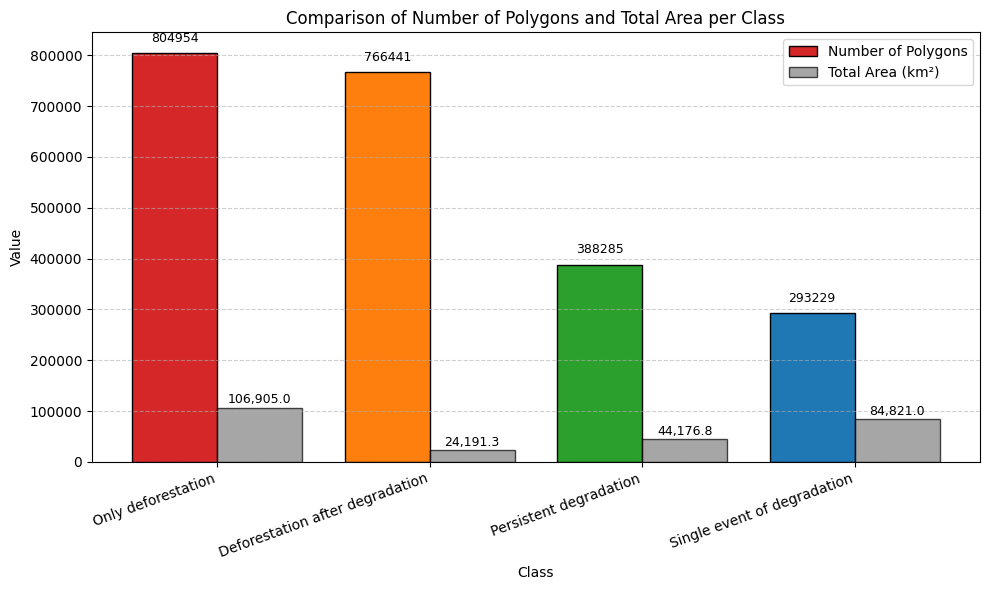

In [39]:
# Aggregate data
class_summary = (
    dg.groupby("class")
    .agg(
        num_polygons=("class", "count"),
        total_area_km2=("area_km2", "sum")
    )
    .reset_index()
)

# Optional: sort classes for readability
class_summary = class_summary.sort_values("num_polygons", ascending=False)

# Define colors
color_map = {
    "Only deforestation": "#d62728",          # red
    "Persistent degradation": "#2ca02c",      # green
    "Single event of degradation": "#1f77b4", # blue
    "Deforestation after degradation": "#ff7f0e"  # orange
}
colors = [color_map.get(c, "gray") for c in class_summary["class"]]

# Define positions
x = np.arange(len(class_summary))  # class positions
width = 0.4  # width of each bar

# Normalize total_area_km2 for visual comparability (optional)
# Comment this line if you want the real area scale on the same axis
# class_summary["total_area_km2"] = class_summary["total_area_km2"] / 100

# Create figure
plt.figure(figsize=(10, 6))

# Bars for number of polygons
plt.bar(x - width/2, class_summary["num_polygons"], width,
        color=colors, edgecolor="black", label="Number of Polygons")

# Bars for total area
plt.bar(x + width/2, class_summary["total_area_km2"], width,
        color="gray", edgecolor="black", alpha=0.7, label="Total Area (km²)")

# Labels and style
plt.xticks(x, class_summary["class"], rotation=20, ha="right")
plt.title("Comparison of Number of Polygons and Total Area per Class")
plt.xlabel("Class")
plt.ylabel("Value")
plt.grid(axis="y", linestyle="--", alpha=0.6)

# Add text labels on top of bars
for i, v in enumerate(class_summary["num_polygons"]):
    plt.text(i - width/2, v + (max(class_summary["num_polygons"]) * 0.02),
             f"{v}", ha="center", va="bottom", fontsize=9)

for i, v in enumerate(class_summary["total_area_km2"]):
    plt.text(i + width/2, v + (max(class_summary["total_area_km2"]) * 0.02),
             f"{v:,.1f}", ha="center", va="bottom", fontsize=9)

plt.legend()
plt.tight_layout()
plt.show()


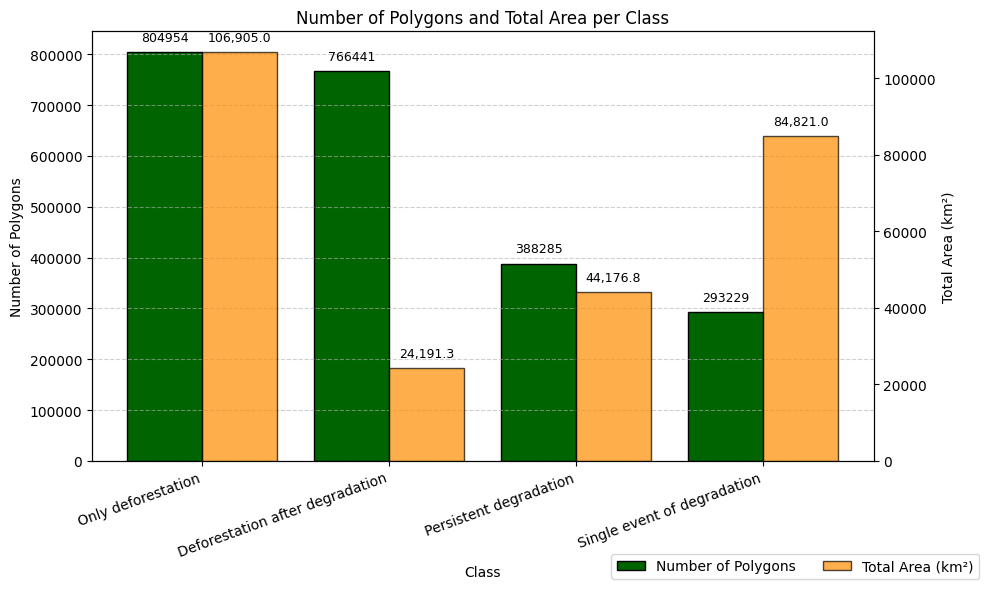

In [40]:
# Aggregate data
class_summary = (
    dg.groupby("class")
    .agg(
        num_polygons=("class", "count"),
        total_area_km2=("area_km2", "sum")
    )
    .reset_index()
)

# Sort classes for readability
class_summary = class_summary.sort_values("num_polygons", ascending=False)

# X positions
x = np.arange(len(class_summary))
bar_width = 0.4

# Create figure with extra bottom space
fig, ax1 = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(bottom=0.25)  # increase bottom margin for legend

# ----------------------------
# Left axis: Number of polygons
# ----------------------------
color_polygons = "darkgreen"
bars1 = ax1.bar(x - bar_width/2, class_summary["num_polygons"], 
                width=bar_width, color=color_polygons, edgecolor="black", label="Number of Polygons")
ax1.set_xlabel("Class")
ax1.set_ylabel("Number of Polygons", color='black')
ax1.tick_params(axis="y", labelcolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(class_summary["class"], rotation=20, ha="right")
ax1.grid(axis="y", linestyle="--", alpha=0.6)

# ----------------------------
# Right axis: Total area
# ----------------------------
ax2 = ax1.twinx()
color_area = "darkorange"
bars2 = ax2.bar(x + bar_width/2, class_summary["total_area_km2"], 
                width=bar_width, color=color_area, alpha=0.7, edgecolor="black", label="Total Area (km²)")
ax2.set_ylabel("Total Area (km²)", color='black')
ax2.tick_params(axis="y", labelcolor='black')

# ----------------------------
# Add text labels
# ----------------------------
for i, v in enumerate(class_summary["num_polygons"]):
    ax1.text(i - bar_width/2, v + (max(class_summary["num_polygons"]) * 0.02),
             f"{v}", ha="center", va="bottom", fontsize=9)

for i, v in enumerate(class_summary["total_area_km2"]):
    ax2.text(i + bar_width/2, v + (max(class_summary["total_area_km2"]) * 0.02),
             f"{v:,.1f}", ha="center", va="bottom", fontsize=9)

# ----------------------------
# Legends below the plot (outside)
# ----------------------------
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
plt.legend(handles=handles1 + handles2, labels=labels1 + labels2, 
           loc='upper center', bbox_to_anchor=(0.9, -0.2), ncol=2)

# ----------------------------
plt.title("Number of Polygons and Total Area per Class")
plt.tight_layout()
plt.show()


In [41]:
# Aggregate data per class
summary = (
    dg.groupby("class")
    .agg(
        num_polygons=("class", "count"),
        total_area_km2=("area_km2", "sum")
    )
    .reset_index()
)

# Calculate percentages
total_polygons = summary["num_polygons"].sum()
total_area = summary["total_area_km2"].sum()

summary["perc_polygons"] = (summary["num_polygons"] / total_polygons * 100).round(2)
summary["perc_area"] = (summary["total_area_km2"] / total_area * 100).round(2)

# Rename columns for clarity
summary = summary.rename(columns={
    "num_polygons": "Number of Polygons",
    "perc_polygons": "Percentage of Polygons (%)",
    "total_area_km2": "Total Area (km²)",
    "perc_area": "Percentage of Total Area (%)"
})

# Optional: sort by number of polygons
summary = summary.sort_values("Number of Polygons", ascending=False)

# Show table
print(summary)


                             class  Number of Polygons  Total Area (km²)  \
1               Only deforestation              804954     106905.011314   
0  Deforestation after degradation              766441      24191.265517   
2           Persistent degradation              388285      44176.815703   
3      Single event of degradation              293229      84821.049349   

   Percentage of Polygons (%)  Percentage of Total Area (%)  
1                       35.73                         41.10  
0                       34.02                          9.30  
2                       17.23                         16.98  
3                       13.02                         32.61  


In [42]:
desmatamento_vindo_degradacao =  24191.265517/(106905.011314+24191.265517)*100
desmatamento_sem_degradacao = 100-desmatamento_vindo_degradacao
print("desmatamento_vindo_degradacao")
print(desmatamento_vindo_degradacao)
print("desmatamento_sem_degradacao")
print(desmatamento_sem_degradacao)

desmatamento_vindo_degradacao
18.45305305518757
desmatamento_sem_degradacao
81.54694694481243


In [43]:
degradacao_virou_desmatamento = 24191.265517/(24191.265517+44176.815703+84821.049349)*100
degradacao_sem_desmatamento = 100-degradacao_virou_desmatamento
print("degradacao_virou_desmatamento")
print(degradacao_virou_desmatamento)
print("degradacao_sem_desmatamento")
print(degradacao_sem_desmatamento)

degradacao_virou_desmatamento
15.791763702258033
degradacao_sem_desmatamento
84.20823629774196


In [44]:
dg.head()

,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,...,deforest,deforestation,dg0824_desm,index_right,Bioma,CD_Bioma,geometry,seq0824,count0824,last_degrad
0,0,0,0,0,0,0,0,0,0,0,...,1,1,both,0,Amazônia,1,"MULTIPOLYGON (((4876148.755 8749082.353, 48761...",00000000001001111,5,2024.0
1,0,1,1,0,0,0,0,1,1,0,...,1,1,both,0,Amazônia,1,"MULTIPOLYGON (((5232158.859 8693312.155, 52321...",11000011001010111,9,2024.0
2,0,1,1,1,0,0,0,0,0,0,...,1,1,both,0,Amazônia,1,"MULTIPOLYGON (((5018567.944 8906527.269, 50185...",11100000001010111,8,2024.0
3,0,1,0,1,0,0,0,0,0,0,...,1,1,both,0,Amazônia,1,"MULTIPOLYGON (((5018581.093 8906518.42, 501856...",10100000001010111,7,2024.0
4,0,1,0,0,0,0,0,0,0,0,...,1,1,both,0,Amazônia,1,"MULTIPOLYGON (((5018601.851 8906431.342, 50186...",10000000001010111,6,2024.0


In [45]:
# Select only "Degradation"
subset1 = dg[
    (
        (dg["class"] == "Deforestation after degradation") |
        (dg["class"] == "Single event of degradation") |
        (dg["class"] == "Persistent degradation")
    )
   ].copy()
print(subset1.shape)
print(subset1[["class","deforest","count0824"]].head(10))


(1447955, 37)
                             class  deforest  count0824
0  Deforestation after degradation         1          5
1  Deforestation after degradation         1          9
2  Deforestation after degradation         1          8
3  Deforestation after degradation         1          7
4  Deforestation after degradation         1          6
5  Deforestation after degradation         1          8
6  Deforestation after degradation         1          8
7  Deforestation after degradation         1          7
8  Deforestation after degradation         1          4
9  Deforestation after degradation         1          4


In [46]:
subset1['class'].describe()

count                             1447955
unique                                  3
top       Deforestation after degradation
freq                               766441
Name: class, dtype: object

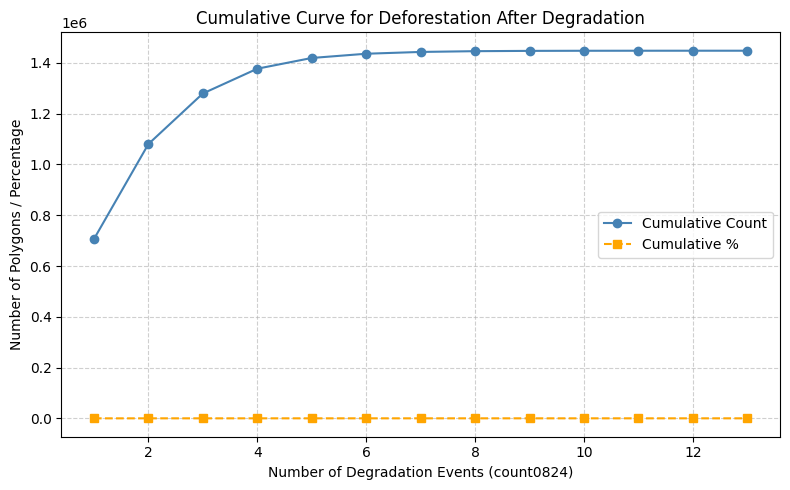

In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure 'count0824' is numeric and fill NaNs with 0
subset1["count0824"] = pd.to_numeric(subset1["count0824"], errors='coerce').fillna(0).astype(int)

# Sort unique degradation counts
events = np.sort(subset1["count0824"].unique())

# Compute cumulative counts
cumulative_counts = [subset1[subset1["count0824"] <= e].shape[0] for e in events]

# Compute cumulative percentage (relative to total polygons in subset)
total_polygons = subset1.shape[0]
cumulative_perc = [count / total_polygons * 100 for count in cumulative_counts]

# ----------------------------
# Plot cumulative curve
# ----------------------------
plt.figure(figsize=(8,5))
plt.plot(events, cumulative_counts, marker='o', linestyle='-', color='steelblue', label='Cumulative Count')
plt.plot(events, cumulative_perc, marker='s', linestyle='--', color='orange', label='Cumulative %')

plt.xlabel("Number of Degradation Events (count0824)")
plt.ylabel("Number of Polygons / Percentage")
plt.title("Cumulative Curve for Deforestation After Degradation")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()



In [91]:
subset1["class"].describe()

count                             1447955
unique                                  3
top       Deforestation after degradation
freq                               766441
Name: class, dtype: object

In [92]:
print(dg["count0824"].unique())
print(dg["count0824"].dtype)

[ 5  9  8  7  6  4 10  3  2  1  0 13 12 11]
int64


C:\Users\lucci\AppData\Local\Programs\Python\Python313\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


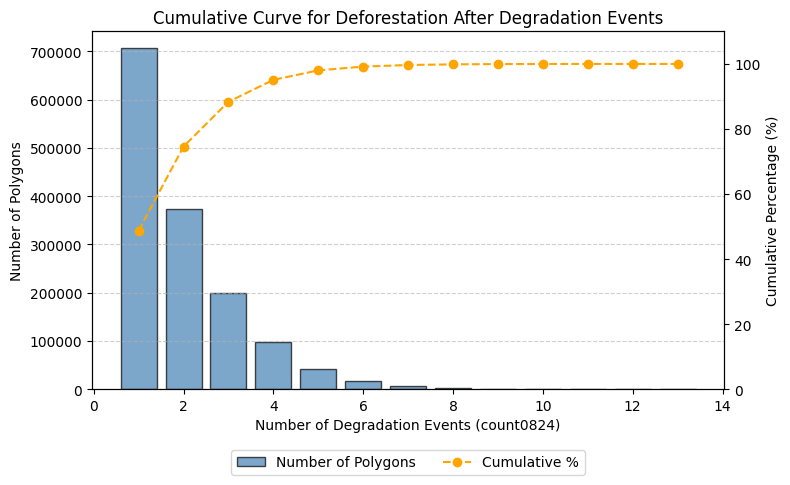

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Step 1: Robust filtering
# ----------------------------
subset1 = dg[
    (
        (dg["class"] == "Deforestation after degradation") |
        (dg["class"] == "Single event of degradation") |
        (dg["class"] == "Persistent degradation")
    )]

if subset1.shape[0] == 0:
    raise ValueError("No polygons found with class='Deforestation after degradation' and deforest=1")

# ----------------------------
# Step 2: Ensure count0824 is numeric
# ----------------------------
subset1["count0824"] = pd.to_numeric(subset1["count0824"], errors='coerce').fillna(0).astype(int)

# ----------------------------
# Step 3: Aggregate counts per number of events
# ----------------------------
count_table = subset1.groupby("count0824").size().sort_index()
counts = count_table.values
events = count_table.index.values

# ----------------------------
# Step 4: Compute cumulative sum and percentage
# ----------------------------
cumulative_counts = np.cumsum(counts)
cumulative_perc = cumulative_counts / cumulative_counts[-1] * 100  # percentage

# ----------------------------
# Step 5: Plot
# ----------------------------
fig, ax1 = plt.subplots(figsize=(8,5))

# Bars: number of polygons
ax1.bar(events, counts, color='steelblue', edgecolor='black', alpha=0.7, label='Number of Polygons')
ax1.set_xlabel("Number of Degradation Events (count0824)")
ax1.set_ylabel("Number of Polygons", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Secondary axis: cumulative percentage
ax2 = ax1.twinx()
ax2.plot(events, cumulative_perc, color='orange', marker='o', linestyle='--', label='Cumulative %')
ax2.set_ylabel("Cumulative Percentage (%)", color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(0, 110)

# Legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
plt.legend(handles=handles1 + handles2, labels=labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

# Title and layout
plt.title("Cumulative Curve for Deforestation After Degradation Events")
plt.tight_layout()
plt.show()


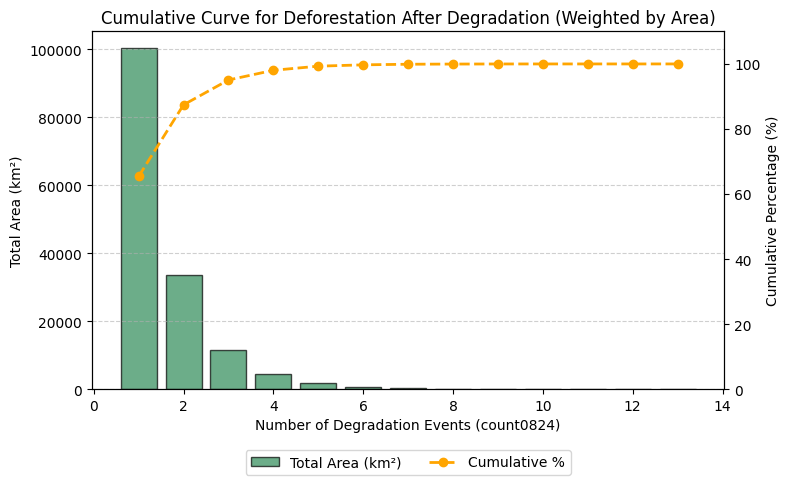

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Step 1: Robust filtering
# ----------------------------
subset1 = dg[
    (
        (dg["class"] == "Deforestation after degradation") |
        (dg["class"] == "Single event of degradation") |
        (dg["class"] == "Persistent degradation")
    )
].copy()

if subset1.shape[0] == 0:
    raise ValueError("No polygons found matching the selected classes.")

# ----------------------------
# Step 2: Ensure numeric columns
# ----------------------------
subset1["count0824"] = pd.to_numeric(subset1["count0824"], errors='coerce').fillna(0).astype(int)
subset1["area_km2"] = pd.to_numeric(subset1["area_km2"], errors='coerce').fillna(0)

# ----------------------------
# Step 3: Aggregate total area per number of events
# ----------------------------
area_table = subset1.groupby("count0824")["area_km2"].sum().sort_index()
areas = area_table.values
events = area_table.index.values

# ----------------------------
# Step 4: Compute cumulative area and percentage
# ----------------------------
cumulative_area = np.cumsum(areas)
cumulative_perc = cumulative_area / cumulative_area[-1] * 100  # percentage

# ----------------------------
# Step 5: Plot
# ----------------------------
fig, ax1 = plt.subplots(figsize=(8,5))

# Bars: total degraded area
ax1.bar(events, areas, color='seagreen', edgecolor='black', alpha=0.7, label='Total Area (km²)')
ax1.set_xlabel("Number of Degradation Events (count0824)")
ax1.set_ylabel("Total Area (km²)", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Secondary axis: cumulative percentage
ax2 = ax1.twinx()
ax2.plot(events, cumulative_perc, color='orange', marker='o', linestyle='--', linewidth=2, label='Cumulative %')
ax2.set_ylabel("Cumulative Percentage (%)", color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(0, 110)

# Legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
plt.legend(
    handles=handles1 + handles2,
    labels=labels1 + labels2,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

# Title and layout
plt.title("Cumulative Curve for Deforestation After Degradation (Weighted by Area)")
plt.tight_layout()
plt.show()


In [95]:
import pandas as pd
import re

# Step 1: Filter polygons
subset = dg[
    (dg["class"].isin(["Deforestation after degradation", "Persistent degradation"]))
].copy()

# Step 2: Function to find longest consecutive 1s
def longest_consecutive_ones(seq):
    """
    seq: string of '0's and '1's (or numeric sequence)
    returns: integer, maximum number of consecutive 1s
    """
    if pd.isna(seq):
        return 0
    seq_str = str(seq)  # Convert to string in case it’s an int or float
    seq_str = seq_str.replace(".", "").replace(" ", "")  # Clean possible artifacts
    if len(seq_str) == 0:
        return 0

    ones = re.findall(r"1+", seq_str)  # find all consecutive sequences of 1s
    if not ones:
        return 0
    return max(len(s) for s in ones)

# Step 3: Apply function to seq0824
subset["max_consecutive"] = subset["seq0824"].apply(longest_consecutive_ones)

# Step 4: Inspect results
print(subset[["seq0824", "count0824", "max_consecutive"]].head(10))
print(subset.head(20))


             seq0824  count0824  max_consecutive
0  00000000001001111          5                4
1  11000011001010111          9                3
2  11100000001010111          8                3
3  10100000001010111          7                3
4  10000000001010111          6                3
5  11000011000010111          8                3
6  11000011000010111          8                3
7  11000001000010111          7                3
8  00000000000001111          4                4
9  00000000000001111          4                4
   2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  ...  \
0     0     0     0     0     0     0     0     0     0     0  ...   
1     0     1     1     0     0     0     0     1     1     0  ...   
2     0     1     1     1     0     0     0     0     0     0  ...   
3     0     1     0     1     0     0     0     0     0     0  ...   
4     0     1     0     0     0     0     0     0     0     0  ...   
5     0     1     1     0     0     0    

In [100]:
dg['count0824']= dg['count0824'].astype(int)

In [101]:
subset['class'].describe()

count                             1154726
unique                                  2
top       Deforestation after degradation
freq                               766441
Name: class, dtype: object

In [49]:
# --- Compute summary statistics ---
mean_val = subset["max_consecutive"].mean()
median_val = subset["max_consecutive"].median()
std_val = subset["max_consecutive"].std()
min_val = subset["max_consecutive"].min()
max_val = subset["max_consecutive"].max()

# --- Plot histogram ---
plt.figure(figsize=(8, 5))
n, bins, patches = plt.hist(
    subset["max_consecutive"],
    bins=range(0, subset["max_consecutive"].max() + 2),
    edgecolor="black",
    alpha=0.7
)

# Add vertical lines for mean and median
plt.axvline(mean_val, color="red", linestyle="dashed", linewidth=1.5, label=f"Mean = {mean_val:.2f}")
plt.axvline(median_val, color="blue", linestyle="dotted", linewidth=1.5, label=f"Median = {median_val:.2f}")

# --- Add summary statistics as text box ---
stats_text = (
    f"Mean: {mean_val:.2f}\n"
    f"Median: {median_val:.2f}\n"
    f"Std: {std_val:.2f}\n"
    f"Min: {min_val}\n"
    f"Max: {max_val}"
)
plt.gca().text(
    0.98, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7)
)

# --- Final styling ---
plt.title("Number of Geometries by Event Count (2008–2024)")
plt.xlabel("Number of Consecutive Years with Event (max_consecutive)")
plt.ylabel("Number of Geometries")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()


NameError: name 'subset' is not defined

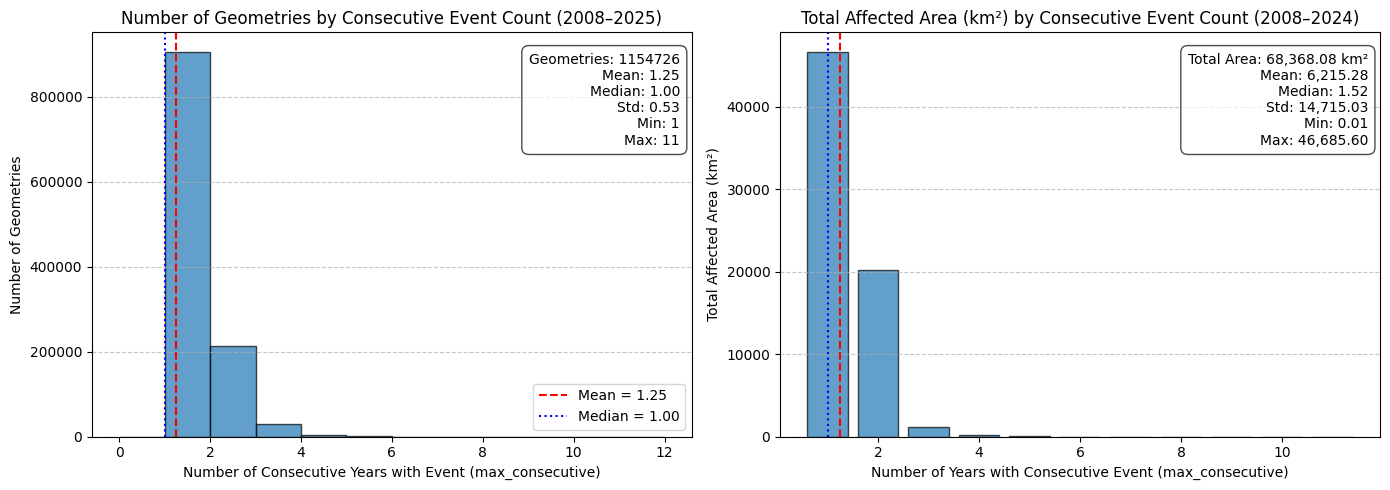

In [103]:
# --- Compute summary stats for count0825 (number of geometries) ---
mean_count = subset["max_consecutive"].mean()
median_count = subset["max_consecutive"].median()
std_count = subset["max_consecutive"].std()
min_count = subset["max_consecutive"].min()
max_count = subset["max_consecutive"].max()
n_geom = len(subset)

# --- Group area by event count and compute summary stats ---
area_by_count = subset.groupby("max_consecutive")["area_km2"].sum().reset_index()
mean_area = area_by_count["area_km2"].mean()
median_area = area_by_count["area_km2"].median()
std_area = area_by_count["area_km2"].std()
min_area = area_by_count["area_km2"].min()
max_area = area_by_count["area_km2"].max()
total_area = subset["area_km2"].sum()

# --- Create figure and subplots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ======================================================
# 1️⃣ Histogram — Number of Geometries
# ======================================================
axes[0].hist(
    subset["max_consecutive"],
    bins=range(0, subset["max_consecutive"].max() + 2),
    edgecolor="black",
    alpha=0.7
)
axes[0].axvline(mean_count, color="red", linestyle="dashed", linewidth=1.5, label=f"Mean = {mean_count:.2f}")
axes[0].axvline(median_count, color="blue", linestyle="dotted", linewidth=1.5, label=f"Median = {median_count:.2f}")

stats_text1 = (
    f"Geometries: {n_geom}\n"
    f"Mean: {mean_count:.2f}\n"
    f"Median: {median_count:.2f}\n"
    f"Std: {std_count:.2f}\n"
    f"Min: {min_count}\n"
    f"Max: {max_count}"
)
axes[0].text(
    0.98, 0.95, stats_text1,
    transform=axes[0].transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7)
)
axes[0].set_title("Number of Geometries by Consecutive Event Count (2008–2025)")
axes[0].set_xlabel("Number of Consecutive Years with Event (max_consecutive)")
axes[0].set_ylabel("Number of Geometries")
axes[0].grid(axis="y", linestyle="--", alpha=0.7)
axes[0].legend()

# ======================================================
# 2️⃣ Bar Chart — Total Affected Area (km²)
# ======================================================
axes[1].bar(
    area_by_count["max_consecutive"],
    area_by_count["area_km2"],
    edgecolor="black",
    alpha=0.7
)

axes[1].axvline(mean_count, color="red", linestyle="dashed", linewidth=1.5, label=f"Mean = {mean_count:.2f}")
axes[1].axvline(median_count, color="blue", linestyle="dotted", linewidth=1.5, label=f"Median = {median_count:.2f}")

stats_text2 = (
    f"Total Area: {total_area:,.2f} km²\n"
    f"Mean: {mean_area:,.2f}\n"
    f"Median: {median_area:,.2f}\n"
    f"Std: {std_area:,.2f}\n"
    f"Min: {min_area:,.2f}\n"
    f"Max: {max_area:,.2f}"
)
axes[1].text(
    0.98, 0.95, stats_text2,
    transform=axes[1].transAxes,
    fontsize=10,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7)
)
axes[1].set_title("Total Affected Area (km²) by Consecutive Event Count (2008–2024)")
axes[1].set_xlabel("Number of Years with Consecutive Event (max_consecutive)")
axes[1].set_ylabel("Total Affected Area (km²)")
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# --- Final layout ---
plt.tight_layout()
plt.show()

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Filter polygons
subset_filtered = subset[subset["count0824"] > 1].copy()

# Step 2: Determine max count0824
max_count = subset_filtered["count0824"].max()

# Step 3: Create categories
# Category 1 = count0824 == 3, Category 2 = count0824 == 4, ...
subset_filtered["category"] = subset_filtered["count0824"]  # Category 1 = 3, etc.

# Step 4: Pivot table - proportion of max_consecutive per category
pivot_table = (
    subset_filtered
    .groupby(["category", "max_consecutive"])
    .size()
    .reset_index(name="count")
)

# Compute proportion per category
pivot_table["proportion"] = pivot_table.groupby("category")["count"].transform(lambda x: x / x.sum())

# Step 5: Display table
print(pivot_table)

# Step 6: Plot stacked bar chart
pivot_plot = pivot_table.pivot(index="category", columns="max_consecutive", values="proportion").fillna(0)

pivot_plot.plot(kind="bar", stacked=True, figsize=(10,6), colormap="tab20")

plt.xlabel("Category (count0824)")
plt.ylabel("Proportion per max_consecutive")
plt.title("Proportion of max_consecutive per count0824 Category")
plt.legend(title="Max Consecutive Years", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


NameError: name 'subset' is not defined

In [168]:
output_path = "C:/Users/lucci/OneDrive/Documentos/OneDrive/11_SOS_AMAZON/01_TrajetoryDegrad/04_DOCS/consecutive_events.xlsx"

# Export to Excel
pivot_table.to_excel(output_path, index=False)

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Filter polygons
subset_filtered = subset[subset["count0824"] >1].copy()

# Step 2: Determine max count0824
max_count = subset_filtered["count0824"].max()

# Step 3: Create categories (Category 1 = 3, Category 2 = 4, etc.)
subset_filtered["category"] = subset_filtered["count0824"]

# Step 4: Pivot table — use area_km2 instead of counts
pivot_table = (
    subset_filtered
    .groupby(["category", "max_consecutive"], as_index=False)["area_km2"]
    .sum()
)

# Step 5: Compute proportional area per category
pivot_table["proportion"] = pivot_table.groupby("category")["area_km2"].transform(lambda x: x / x.sum())

# Step 6: Display table
print(pivot_table)

# Step 7: Prepare for plotting
pivot_plot = pivot_table.pivot(index="category", columns="max_consecutive", values="proportion").fillna(0)

# Step 8: Plot stacked bar chart
pivot_plot.plot(kind="bar", stacked=True, figsize=(10,6), colormap="tab20")

plt.xlabel("Category (count0824)")
plt.ylabel("Proportion of Affected Area")
plt.title("Proportion of Affected Area by Max Consecutive Degradation (weighted by area_km2)")
plt.legend(title="Max Consecutive Years", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

NameError: name 'subset' is not defined

    category  years_after_degrad     area_km2  proportion
0          2                 0.0  1130.479468    0.254758
1          2                 1.0   916.872843    0.206621
2          2                 2.0   687.799987    0.154998
3          2                 3.0   462.412426    0.104206
4          2                 4.0   335.590798    0.075627
..       ...                 ...          ...         ...
83        10                 1.0     0.005758    0.003491
84        10                 2.0     0.420857    0.255146
85        11                 0.0     0.804511    0.993892
86        11                 1.0     0.004944    0.006108
87        12                 0.0     0.506587    1.000000

[88 rows x 4 columns]


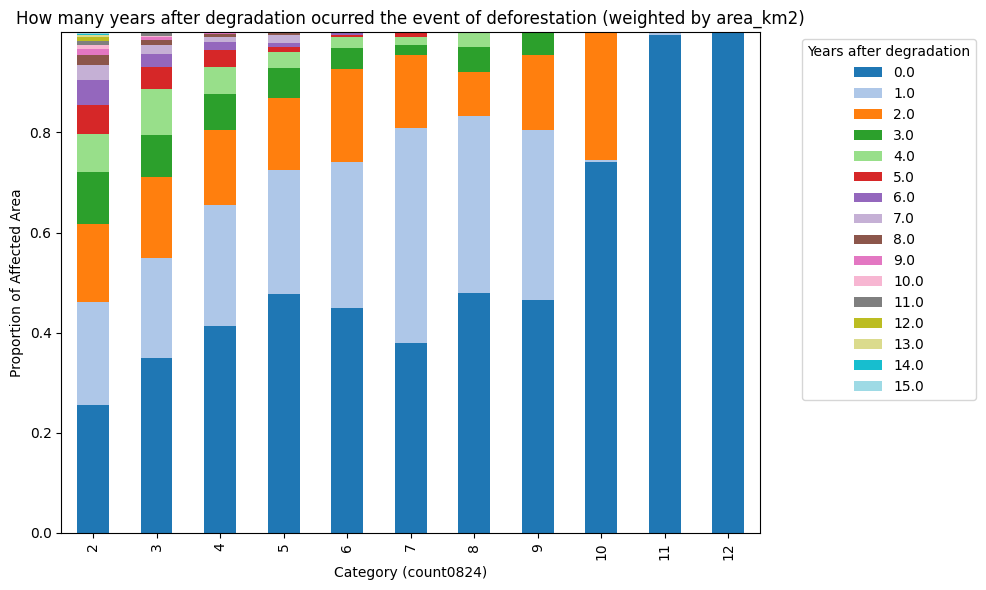

In [111]:
import pandas as pd
import matplotlib.pyplot as plt

subset = dg[
    (dg["class"].isin(["Deforestation after degradation"]))
].copy()

# Step 1: Filter polygons
subset_filtered = subset[subset["count0824"] >1].copy()

# Step 2: Determine max count0824
max_count = subset_filtered["count0824"].max()

# Step 3: Create categories (Category 1 = 3, Category 2 = 4, etc.)
subset_filtered["category"] = subset_filtered["count0824"]

# Step 4: Pivot table — use area_km2 instead of counts
pivot_table = (
    subset_filtered
    .groupby(["category", "years_after_degrad"], as_index=False)["area_km2"]
    .sum()
)

# Step 5: Compute proportional area per category
pivot_table["proportion"] = pivot_table.groupby("category")["area_km2"].transform(lambda x: x / x.sum())

# Step 6: Display table
print(pivot_table)

# Step 7: Prepare for plotting
pivot_plot = pivot_table.pivot(index="category", columns="years_after_degrad", values="proportion").fillna(0)

# Step 8: Plot stacked bar chart
pivot_plot.plot(kind="bar", stacked=True, figsize=(10,6), colormap="tab20")

plt.xlabel("Category (count0824)")
plt.ylabel("Proportion of Affected Area")
plt.title("How many years after degradation ocurred the event of deforestation (weighted by area_km2)")
plt.legend(title="Years after degradation", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [112]:
output_path = "C:/Users/lucci/OneDrive/Documentos/OneDrive/11_SOS_AMAZON/01_TrajetoryDegrad/04_DOCS/consecutive_events_yearsafter.xlsx"

# Export to Excel
pivot_table.to_excel(output_path, index=False)

In [106]:
output_path = "C:/Users/lucci/OneDrive/Documentos/OneDrive/11_SOS_AMAZON/01_TrajetoryDegrad/04_DOCS/consecutive_events_area.xlsx"

# Export to Excel
pivot_table.to_excel(output_path, index=False)

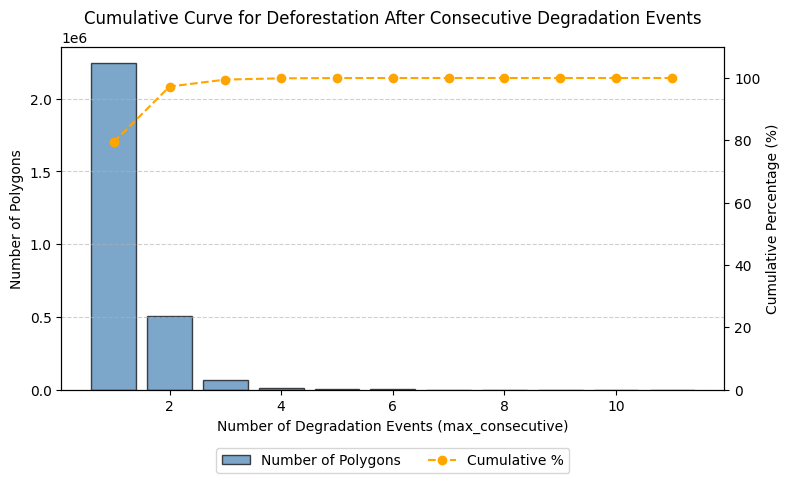

In [172]:
if subset.shape[0] == 0:
    raise ValueError("No polygons found with class='Deforestation after degradation' and deforest=1")

# ----------------------------
# Step 2: Ensure count0824 is numeric
# ----------------------------
subset["max_consecutive"] = pd.to_numeric(subset["max_consecutive"], errors='coerce').fillna(0).astype(int)

# ----------------------------
# Step 3: Aggregate counts per number of events
# ----------------------------
count_table = subset.groupby("max_consecutive").size().sort_index()
counts = count_table.values
events = count_table.index.values

# ----------------------------
# Step 4: Compute cumulative sum and percentage
# ----------------------------
cumulative_counts = np.cumsum(counts)
cumulative_perc = cumulative_counts / cumulative_counts[-1] * 100  # percentage

# ----------------------------
# Step 5: Plot
# ----------------------------
fig, ax1 = plt.subplots(figsize=(8,5))

# Bars: number of polygons
ax1.bar(events, counts, color='steelblue', edgecolor='black', alpha=0.7, label='Number of Polygons')
ax1.set_xlabel("Number of Degradation Events (max_consecutive)")
ax1.set_ylabel("Number of Polygons", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Secondary axis: cumulative percentage
ax2 = ax1.twinx()
ax2.plot(events, cumulative_perc, color='orange', marker='o', linestyle='--', label='Cumulative %')
ax2.set_ylabel("Cumulative Percentage (%)", color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(0, 110)

# Legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
plt.legend(handles=handles1 + handles2, labels=labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

# Title and layout
plt.title("Cumulative Curve for Deforestation After Consecutive Degradation Events")
plt.tight_layout()
plt.show()

    category deforest_label      area_km2    proportion
0          2     Deforested  3.466083e+03  1.713319e-01
1          2         Forest  1.676414e+04  8.286681e-01
2          3     Deforested  4.185264e+02  3.557385e-01
3          3         Forest  7.579738e+02  6.442615e-01
4          4     Deforested  4.531330e+01  1.942434e-01
5          4         Forest  1.879677e+02  8.057566e-01
6          5     Deforested  6.678959e+00  1.747032e-01
7          5         Forest  3.155136e+01  8.252968e-01
8          6     Deforested  3.765290e-01  4.749376e-01
9          6         Forest  4.162678e-01  5.250624e-01
10         7     Deforested  4.708718e-01  8.117566e-01
11         7         Forest  1.091934e-01  1.882434e-01
12         8     Deforested  8.753593e-01  5.747902e-01
13         8         Forest  6.475603e-01  4.252098e-01
14         9     Deforested  5.012641e-03  4.110569e-01
15         9         Forest  7.181877e-03  5.889431e-01
16        10     Deforested  5.065872e-01  9.214

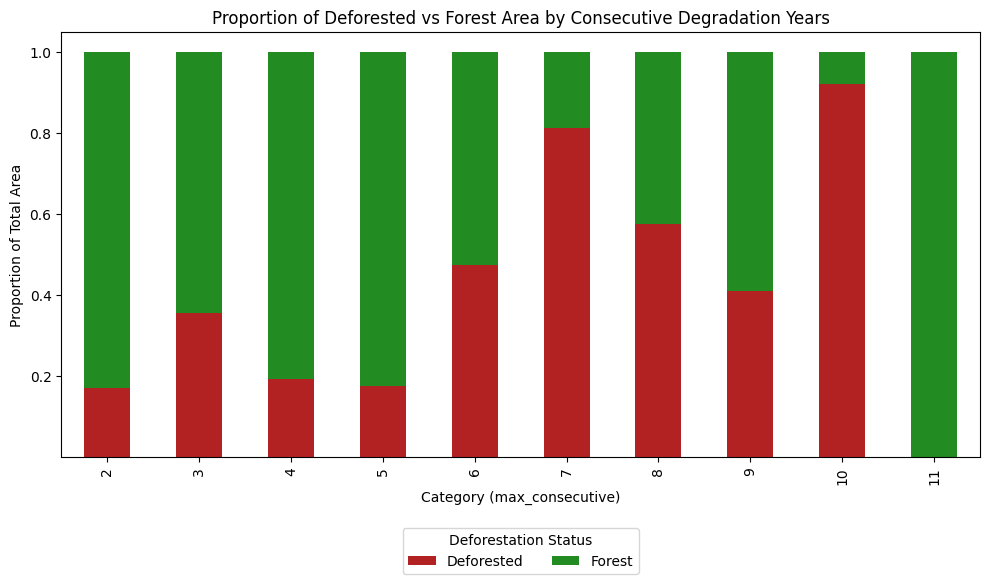

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Step 1: Filter polygons
# ----------------------------
subset_filtered = subset[subset["max_consecutive"] > 1].copy()

# ----------------------------
# Step 2: Ensure numeric columns
# ----------------------------
subset_filtered["max_consecutive"] = pd.to_numeric(subset_filtered["max_consecutive"], errors='coerce').fillna(0).astype(int)
subset_filtered["deforest"] = pd.to_numeric(subset_filtered["deforest"], errors='coerce').fillna(0).astype(int)
subset_filtered["area_km2"] = pd.to_numeric(subset_filtered["area_km2"], errors='coerce').fillna(0)

# ----------------------------
# Step 3: Define category based on max_consecutive
# ----------------------------
subset_filtered["category"] = subset_filtered["max_consecutive"]

# ----------------------------
# Step 4: Replace deforest codes with labels
# ----------------------------
subset_filtered["deforest_label"] = subset_filtered["deforest"].map({1: "Deforested", 0: "Forest"})

# ----------------------------
# Step 5: Group by category and deforest_label, summing area
# ----------------------------
pivot_table = (
    subset_filtered
    .groupby(["category", "deforest_label"], as_index=False)["area_km2"]
    .sum()
)

# ----------------------------
# Step 6: Compute proportional area per category
# ----------------------------
pivot_table["proportion"] = pivot_table.groupby("category")["area_km2"].transform(lambda x: x / x.sum())

# ----------------------------
# Step 7: Display table
# ----------------------------
print(pivot_table)

# ----------------------------
# Step 8: Prepare data for plotting
# ----------------------------
pivot_plot = pivot_table.pivot(index="category", columns="deforest_label", values="proportion").fillna(0)

# ----------------------------
# Step 9: Plot stacked bar chart
# ----------------------------
pivot_plot.plot(kind="bar", stacked=True, figsize=(10, 6), color=["firebrick", "forestgreen"])

plt.xlabel("Category (max_consecutive)")
plt.ylabel("Proportion of Total Area")
plt.title("Proportion of Deforested vs Forest Area by Consecutive Degradation Years")
plt.legend(title="Deforestation Status", bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=2)
plt.tight_layout()
plt.show()


In [109]:
output_path = "C:/Users/lucci/OneDrive/Documentos/OneDrive/11_SOS_AMAZON/01_TrajetoryDegrad/04_DOCS/consecutive_events_deforestation.xlsx"

# Export to Excel
pivot_table.to_excel(output_path, index=False)

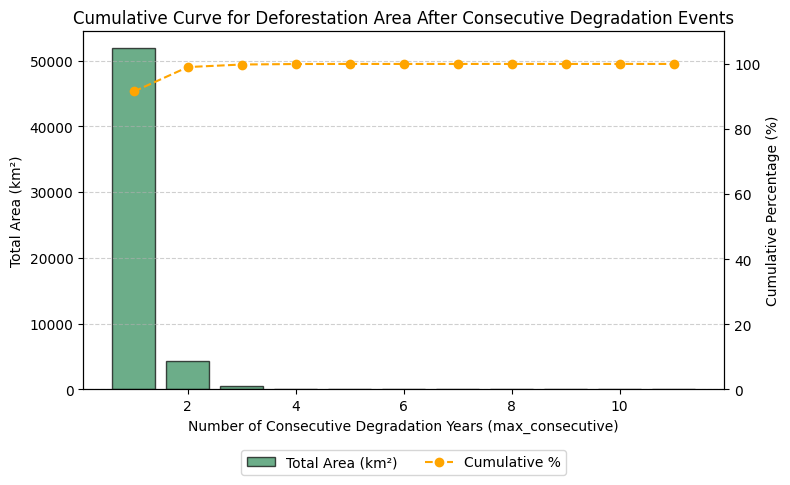

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Step 1: Validation
# ----------------------------
if subset.shape[0] == 0:
    raise ValueError("No polygons found with class='Deforestation after degradation' and deforest=1")

# ----------------------------
# Step 2: Ensure numeric columns
# ----------------------------
subset["max_consecutive"] = pd.to_numeric(subset["max_consecutive"], errors='coerce').fillna(0).astype(int)
subset["area_km2"] = pd.to_numeric(subset["area_km2"], errors='coerce').fillna(0)

# ----------------------------
# Step 3: Aggregate total area per number of consecutive events
# ----------------------------
area_table = subset.groupby("max_consecutive")["area_km2"].sum().sort_index()
areas = area_table.values
events = area_table.index.values

# ----------------------------
# Step 4: Compute cumulative sum and percentage (based on area)
# ----------------------------
cumulative_area = np.cumsum(areas)
cumulative_perc = cumulative_area / cumulative_area[-1] * 100  # percentage

# ----------------------------
# Step 5: Plot
# ----------------------------
fig, ax1 = plt.subplots(figsize=(8,5))

# Bars: total area
ax1.bar(events, areas, color='seagreen', edgecolor='black', alpha=0.7, label='Total Area (km²)')
ax1.set_xlabel("Number of Consecutive Degradation Years (max_consecutive)")
ax1.set_ylabel("Total Area (km²)", color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(axis='y', linestyle='--', alpha=0.6)

# Secondary axis: cumulative percentage
ax2 = ax1.twinx()
ax2.plot(events, cumulative_perc, color='orange', marker='o', linestyle='--', label='Cumulative %')
ax2.set_ylabel("Cumulative Percentage (%)", color='black')
ax2.tick_params(axis='y', labelcolor='black')
ax2.set_ylim(0, 110)

# Legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
plt.legend(
    handles=handles1 + handles2,
    labels=labels1 + labels2,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)

# Title and layout
plt.title("Cumulative Curve for Deforestation Area After Consecutive Degradation Events")
plt.tight_layout()
plt.show()


In [56]:
output_path = "C:/Users/lucci/OneDrive/Documentos/OneDrive/11_SOS_AMAZON/01_TrajetoryDegrad/04_DOCS/consecutive_events_area.xlsx"

# Export to Excel
pivot_table.to_excel(output_path, index=False)

In [11]:
# If you want to save the result to a new GPKG layer:
output_path = "C:/Users/lucci/OneDrive/Documentos/OneDrive/11_SOS_AMAZON/01_TrajetoryDegrad/01_Dados/04_PROCESSADOS/03_DEGRADACAO_DESMATAMENTO/Traj_DEGRAD_DETER_PRODES_2007_2025_pol_FINAL_class_bioma_amz.gpkg"
dg.to_file(output_path, layer="dg", driver="GPKG")

In [7]:
# If you want to save the result to a new GPKG layer:
output_path = "C:/Users/lucci/OneDrive/Documentos/OneDrive/11_SOS_AMAZON/01_TrajetoryDegrad/01_Dados/04_PROCESSADOS/03_DEGRADACAO_DESMATAMENTO/Traj_DEGRAD_DETER_PRODES_2007_2025_pol_FINAL_class_bioma_amz.shp"
degradacao.to_file(output_path, layer="degradacao", driver="ESRI Shapefile")

C:\Users\lucci\AppData\Local\Temp\ipykernel_7508\2751829813.py:3: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  degradacao.to_file(output_path, layer="degradacao", driver="ESRI Shapefile")
C:\Users\lucci\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'years_after_degrad' to 'years_afte'
  ogr_write(
C:\Users\lucci\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'deforestation' to 'deforestat'
  ogr_write(
C:\Users\lucci\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'dg0824_desm' to 'dg0824_des'
  ogr_write(
C:\Users\lucci\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'index_right' to 'index_righ'
  ogr_write(
C:\Use